In [2]:
import sys 
sys.path.append('../')
import comparison_utils
import damask
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import matflow as mf
#import pyvista as pv
import scipy
import skimage

#pv.set_jupyter_backend("trame")

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Nimbus Roman'

# Macro stress-strain response

In [3]:
pheno_file = './phenopowerlaw/phenopowerlaw_128_rolled_copper_200_grains_5k_time_steps_2026-08-28_104710/execute/t_1/geom_load.hdf5'
pheno_wk = './phenopowerlaw/phenopowerlaw_128_rolled_copper_200_grains_5k_time_steps_2026-08-28_104710'
dislo_file = './dislo_density/dislotwin_128_rolled_copper_200_grains_5k_time_steps_2026-08-28_104634/execute/t_1/geom_load.hdf5'
dislo_wk = './dislo_density/dislotwin_128_rolled_copper_200_grains_5k_time_steps_2026-08-28_104634'

In [4]:
def extract_stress_strain_matflow(wk):
    mf_wk = mf.Workflow(wk)
    elements = mf_wk.tasks.simulate_VE_loading_damask.elements
    for element in elements:
        true_strain = np.asarray(element.get("outputs.VE_response.phase_data.vol_avg_strain.data")[:,0,0])
        true_stress = np.asarray(element.get("outputs.VE_response.phase_data.vol_avg_stress.data")[:,0,0])
    return true_strain, true_stress

In [5]:
dislo_strain, dislo_stress = extract_stress_strain_matflow(dislo_wk)
pheno_strain, pheno_stress = extract_stress_strain_matflow(pheno_wk)

In [6]:
pheno_stress_MPa = pheno_stress/(np.ones_like(pheno_stress)*1e6)
dislo_stress_MPa = dislo_stress/(np.ones_like(dislo_stress)*1e6)

Define experimental error bounds

In [ ]:
pheno_exp_err = comparison_utils.define_exp_error(pheno_strain, pheno_stress_MPa, prop_uncertainty=0.09622441625786665)
dislo_exp_err = comparison_utils.define_exp_error(dislo_strain, dislo_stress_MPa, prop_uncertainty=0.04642287717700858)

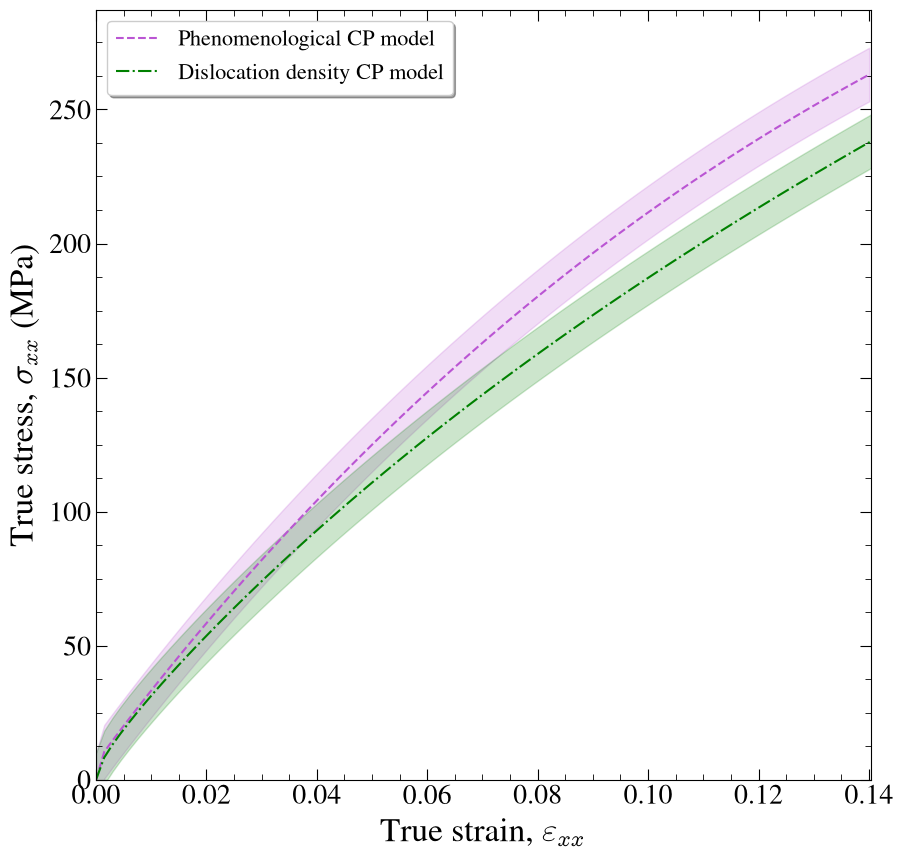

In [9]:
%matplotlib inline
fig = plt.figure(figsize = (10,10))
ax = fig.add_subplot(1,1,1)

#ax.set_title('Polycrystal comparison from single crystal \n parallel calibration values', fontsize = 20, pad = 15)
ax.plot(pheno_strain, pheno_stress_MPa, label = 'Phenomenological CP model', ls = '--', marker = 'None', color = 'mediumorchid', ms = 12)
ax.plot(dislo_strain, dislo_stress_MPa, label = 'Dislocation density CP model', ls = '-.', marker = 'None', color = 'green', ms = 12)
#ax.fill_between(dislo_32_true_strain, dislo_32_true_stress_MPa - 2*dislo_exp_err, dislo_32_true_stress_MPa + 2*dislo_exp_err, color = 'green', alpha = 0.2)

#ax.fill_between(pheno_50k_true_strain, pheno_50k_true_stress_MPa - 2*pheno_exp_err, pheno_50k_true_stress_MPa + 2*pheno_exp_err, color = 'mediumorchid', alpha = 0.2)

#ax.fill_between(pheno_50k_true_strain, pheno_50k_true_stress_MPa - 9, pheno_50k_true_stress_MPa + 9, color = 'mediumorchid', alpha = 0.2)
ax.fill_between(pheno_strain, pheno_stress_MPa - 10, pheno_stress_MPa + 10, color = 'mediumorchid', alpha = 0.2)
ax.fill_between(dislo_strain, dislo_stress_MPa - 10, dislo_stress_MPa + 10, color = 'green', alpha = 0.2)

#ax.fill_between(pheno_strain, pheno_stress_MPa - 0.06*pheno_stress_MPa, pheno_stress_MPa + 0.06*pheno_stress_MPa, color = 'mediumorchid', alpha = 0.2)
#ax.fill_between(dislo_strain, dislo_stress_MPa - 0.06*dislo_stress_MPa, dislo_stress_MPa + 0.06*dislo_stress_MPa, color = 'green', alpha = 0.2)


ax.set_xlabel(r'True strain, $\varepsilon_{xx}$', fontsize = 24, math_fontfamily = 'cm')
ax.set_ylabel(r'True stress, $\sigma_{xx}$ (MPa)', fontsize = 24, math_fontfamily = 'cm')
ax.set_xlim(0,max(max(dislo_strain), max(pheno_strain)))
ax.set_ylim(0)
ax.tick_params(which = 'both', direction = 'in', top = True, right = True, labelsize = 20)
ax.tick_params(which = 'minor', length = 4)
ax.tick_params(which = 'major', length = 8)
ax.xaxis.set_minor_locator(AutoMinorLocator(4))
ax.yaxis.set_minor_locator(AutoMinorLocator(4))

ax.legend(fontsize = 16, shadow = True)
#plt.savefig('./rolled_copper_polycrystal_stress_comparison.png', dpi=800)

# 1. Strain comparison

In [4]:
def extract_full_xx_strain(file, rve_shape):

    result = damask.Result(file)

    x = result.view(increments = result.increments[-1])
    strain = x.get('epsilon_V^0(F)')
    strain_xx = strain[:,0,0]
    strain_map = strain_xx.reshape(rve_shape,order='F')

    return strain_map

In [5]:
def extract_equiv_vM_strain(file, rve_shape):

    result = damask.Result(file)

    x = result.view(increments = result.increments[-1])
    strain = x.get('epsilon_V^0(F)')
    equiv_vM_strain = damask.mechanics.equivalent_strain_Mises(strain)
    equiv_vM_strain_map = equiv_vM_strain.reshape(rve_shape,order='F')

    return equiv_vM_strain_map


Extracting $\varepsilon_{xx}$

In [11]:
dislo_xx_strain = extract_full_xx_strain(dislo_file, rve_shape = [128,128,128])
pheno_xx_strain = extract_full_xx_strain(pheno_file, rve_shape = [128,128,128])

np.save('dislo_128_xx_strain_200_grains.npy', dislo_xx_strain)
np.save('pheno_128_xx_strain_200_grains.npy', pheno_xx_strain)

/mnt/iusers01/jf01/j38714mw/software/venvs/matflow_v4-venv/lib/python3.11/site-packages/numpy/lib/format.py:362: UserWarning: metadata on a dtype is not saved to an npy/npz. Use another format (such as pickle) to store it.
  d['descr'] = dtype_to_descr(array.dtype)


In [12]:
dislo_xx_strain_load = np.load('dislo_128_xx_strain_200_grains.npy')
pheno_xx_strain_load = np.load('pheno_128_xx_strain_200_grains.npy')
dislo_xx_strain_load.shape, pheno_xx_strain_load.shape

((128, 128, 128), (128, 128, 128))

In [13]:
pheno_xx_strain_flat = dislo_xx_strain_load.flatten()
dislo_xx_strain_flat = pheno_xx_strain_load.flatten()

Extracting equivalent von Mises strain

In [6]:
dislo_vM_strain = extract_equiv_vM_strain(dislo_file, rve_shape = [128,128,128])
pheno_vM_strain = extract_equiv_vM_strain(pheno_file, rve_shape = [128,128,128])

np.save('dislo_vM_strain_200_grains.npy', dislo_vM_strain)
np.save('pheno_vM_strain_200_grains.npy', pheno_vM_strain)

/mnt/iusers01/jf01/j38714mw/software/venvs/matflow_v4-venv/lib/python3.11/site-packages/numpy/lib/_format_impl.py:393: UserWarning: metadata on a dtype is not saved to an npy/npz. Use another format (such as pickle) to store it.
  d['descr'] = dtype_to_descr(array.dtype)


In [7]:
dislo_vM_strain_load = np.load('dislo_vM_strain_200_grains.npy')
pheno_vM_strain_load = np.load('pheno_vM_strain_200_grains.npy')
dislo_vM_strain_load.shape, pheno_vM_strain_load.shape

((128, 128, 128), (128, 128, 128))

In [9]:
pheno_vM_strain_flat = dislo_vM_strain_load.flatten()
dislo_vM_strain_flat = pheno_vM_strain_load.flatten()

-0.05187049631960843 0.04754596851087576


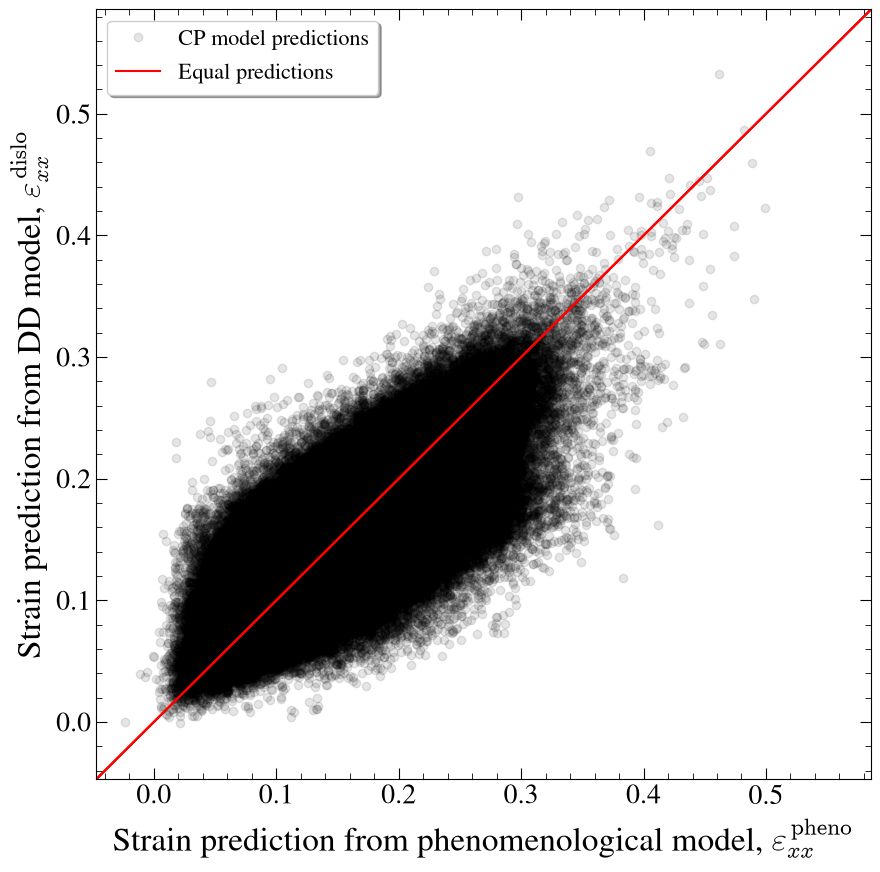

In [14]:
%matplotlib inline
comparison_utils.comparison_plot(pheno_xx_strain_flat, dislo_xx_strain_flat,
                                diag_line_start=[min(min(pheno_xx_strain_flat), min(dislo_xx_strain_flat)) - np.abs(min(min(pheno_xx_strain_flat), min(dislo_xx_strain_flat))), min(min(pheno_xx_strain_flat), min(dislo_xx_strain_flat)) - np.abs(min(min(pheno_xx_strain_flat), min(dislo_xx_strain_flat)))],
                                min_interval=min(min(pheno_xx_strain_flat), min(dislo_xx_strain_flat)) - np.abs(min(min(pheno_xx_strain_flat), min(dislo_xx_strain_flat))),
                                max_interval = max(max(pheno_xx_strain_flat), max(dislo_xx_strain_flat)) + 0.1*np.abs(max(max(pheno_xx_strain_flat), max(dislo_xx_strain_flat))),
                                xlabel = r'Strain prediction from phenomenological model, $\varepsilon_{xx}^{\text{pheno}}$',
                                ylabel = r'Strain prediction from DD model, $\varepsilon_{xx}^{\text{dislo}}$',
                                add_r2_score=False
                                )
#plt.savefig('final_VE_strain_predictions_comparison.png', dpi = 800)

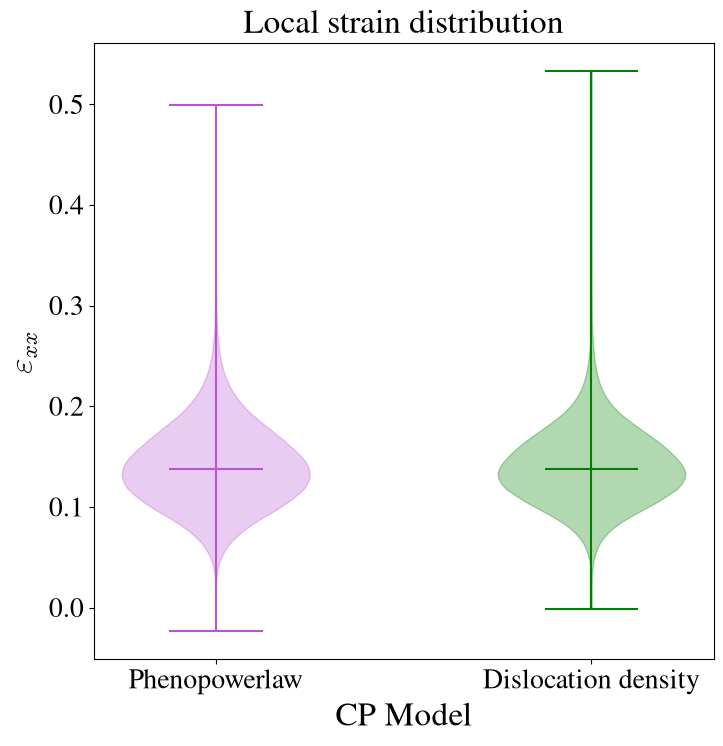

In [15]:
%matplotlib inline
comparison_utils.violin_plot(pheno_xx_strain_flat, dislo_xx_strain_flat, title = 'Local strain distribution', qoi = r'$\varepsilon_{xx}$')
#plt.savefig('local_strain_violin_plot.png', dpi = 800)

Equivalent von Mises strain maps

-0.0698197154346732 0.05731497066084347


/mnt/iusers01/jf01/j38714mw/software/venvs/matflow_v4-venv/lib/python3.11/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/mnt/iusers01/jf01/j38714mw/software/venvs/matflow_v4-venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


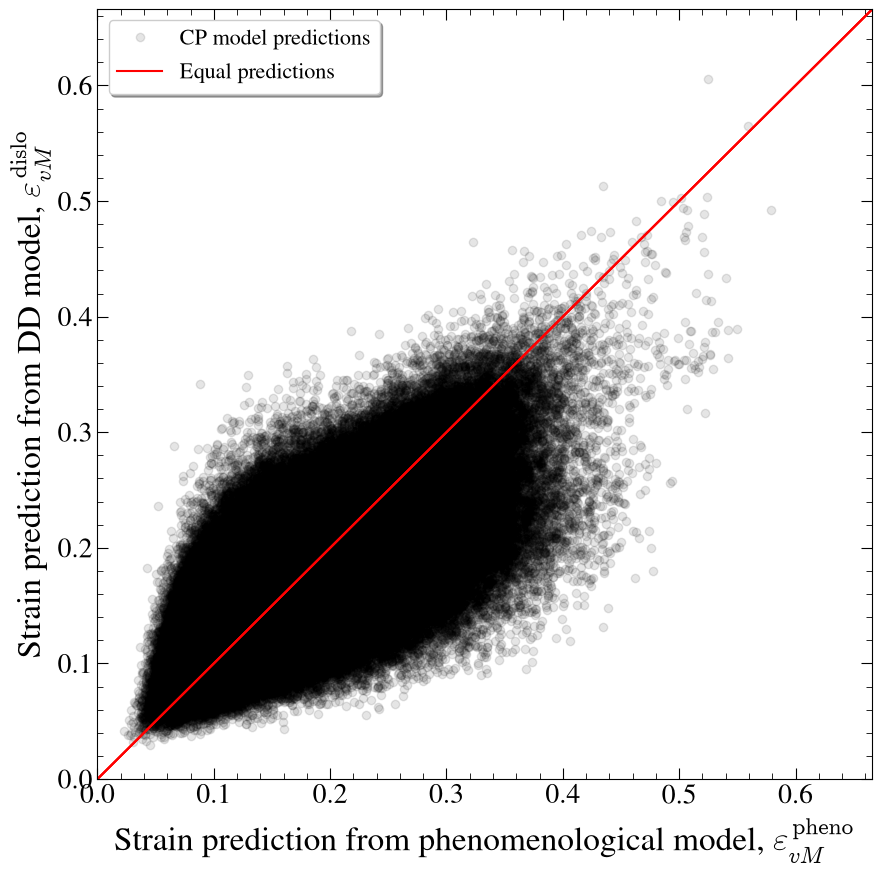

In [ ]:
%matplotlib inline
comparison_utils.comparison_plot(pheno_vM_strain_flat, dislo_vM_strain_flat,
                                diag_line_start=[min(min(pheno_vM_strain_flat), min(dislo_vM_strain_flat)) - np.abs(min(min(pheno_vM_strain_flat), min(dislo_vM_strain_flat))), min(min(pheno_vM_strain_flat), min(dislo_vM_strain_flat)) - np.abs(min(min(pheno_vM_strain_flat), min(dislo_vM_strain_flat)))],
                                min_interval=min(min(pheno_vM_strain_flat), min(dislo_vM_strain_flat)) - np.abs(min(min(pheno_vM_strain_flat), min(dislo_vM_strain_flat))),
                                max_interval = max(max(pheno_vM_strain_flat), max(dislo_vM_strain_flat)) + 0.1*np.abs(max(max(pheno_vM_strain_flat), max(dislo_vM_strain_flat))),
                                xlabel = r'Strain prediction from phenomenological model, $\varepsilon_{\text{vM}}^{\text{pheno}}$',
                                ylabel = r'Strain prediction from DD model, $\varepsilon_{\text{vM}}^{\text{dislo}}$',
                                add_r2_score=False
                                )

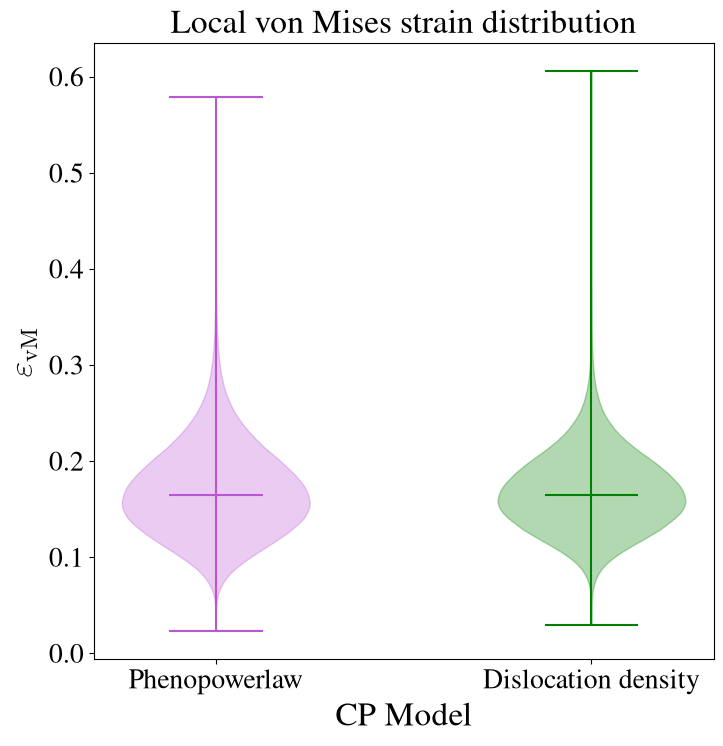

In [11]:
%matplotlib inline
comparison_utils.violin_plot(pheno_vM_strain_flat, dislo_vM_strain_flat, title = 'Local von Mises strain distribution', qoi = r'$\varepsilon_{\text{vM}}$')

Strain maps

In [12]:
def comparison_map(data1, data2, data1_label, data2_label, color_bar_label):    
    fig, ax = plt.subplots(1,2, figsize = (10,6), sharey = True, sharex=True, constrained_layout=True)
    im_1 = ax[0].imshow(data1, vmin = min(min(value) for value in (data1.flatten(), data2.flatten())), vmax = max(max(value) for value in(data1.flatten(), data2.flatten())))
    im_2 = ax[1].imshow(data2, vmin = min(min(value) for value in (data1.flatten(), data2.flatten())), vmax = max(max(value) for value in (data1.flatten(), data2.flatten())))
    cbar = fig.colorbar(im_2, orientation = 'vertical', shrink = 0.73)
    cbar.set_label(color_bar_label, rotation = 90, fontsize = 16, math_fontfamily = 'cm')
    ax[0].set_title(f'{data1_label}', fontsize = 16)
    ax[1].set_title(f'{data2_label}', fontsize = 16)
    ax[0].set_xticks([])
    ax[1].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_yticks([])

In [16]:
pheno_xx_surface_strain = pheno_xx_strain_load[:,:,0].transpose()
dislo_xx_surface_strain = dislo_xx_strain_load[:,:,0].transpose()

pheno_xx_surface_strain_flip = np.flip(pheno_xx_surface_strain, axis=0)
dislo_xx_surface_strain_flip = np.flip(dislo_xx_surface_strain, axis=0)

[]

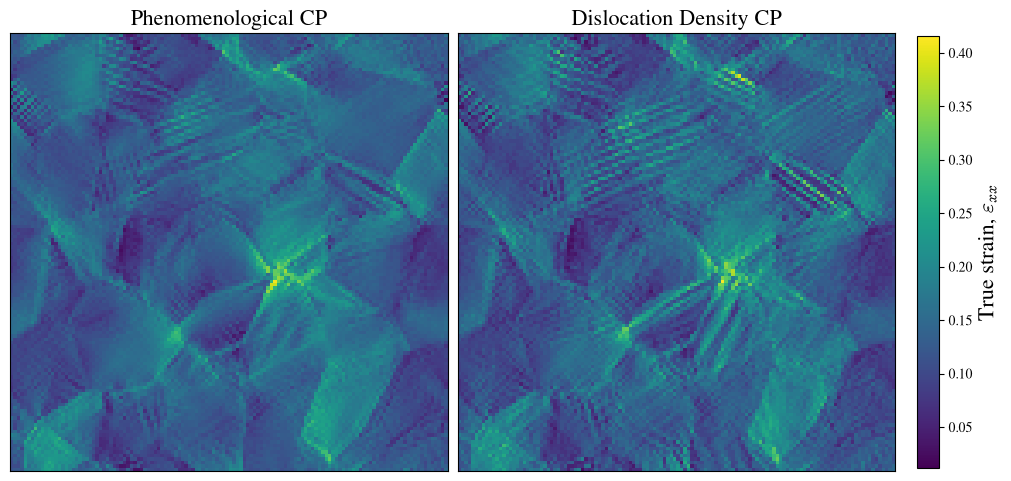

In [17]:
%matplotlib inline

fig_load_strain, ax_load_strain = plt.subplots(1,2, figsize = (10,6), sharey = True, sharex=True, constrained_layout=True)

pheno_load_strain_im = ax_load_strain[0].imshow(pheno_xx_surface_strain_flip, vmin = min(min(value) for value in (pheno_xx_surface_strain_flip.flatten(), dislo_xx_surface_strain_flip.flatten())), vmax = max(max(value) for value in (pheno_xx_surface_strain_flip.flatten(), dislo_xx_surface_strain_flip.flatten())))
dislo_load_strain_im = ax_load_strain[1].imshow(dislo_xx_surface_strain_flip, vmin = min(min(value) for value in (pheno_xx_surface_strain_flip.flatten(), dislo_xx_surface_strain_flip.flatten())), vmax = max(max(value) for value in (pheno_xx_surface_strain_flip.flatten(), dislo_xx_surface_strain_flip.flatten())))
#cbar1 = fig.colorbar(pheno_strain_im, orientation = 'vertical')
cbar_load = fig_load_strain.colorbar(dislo_load_strain_im, orientation = 'vertical', shrink = 0.73)
#cbar1.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
cbar_load.set_label(r'True strain, $\varepsilon_{xx}$', rotation = 90, fontsize = 16, math_fontfamily = 'cm')
ax_load_strain[0].set_title('Phenomenological CP', fontsize = 16)
ax_load_strain[1].set_title('Dislocation Density CP', fontsize = 16)
ax_load_strain[0].set_xticks([])
ax_load_strain[1].set_xticks([])
ax_load_strain[0].set_yticks([])
ax_load_strain[1].set_yticks([])
#plt.savefig('surface_strain_comparison.png', dpi = 800)

Equivalent vM strain map

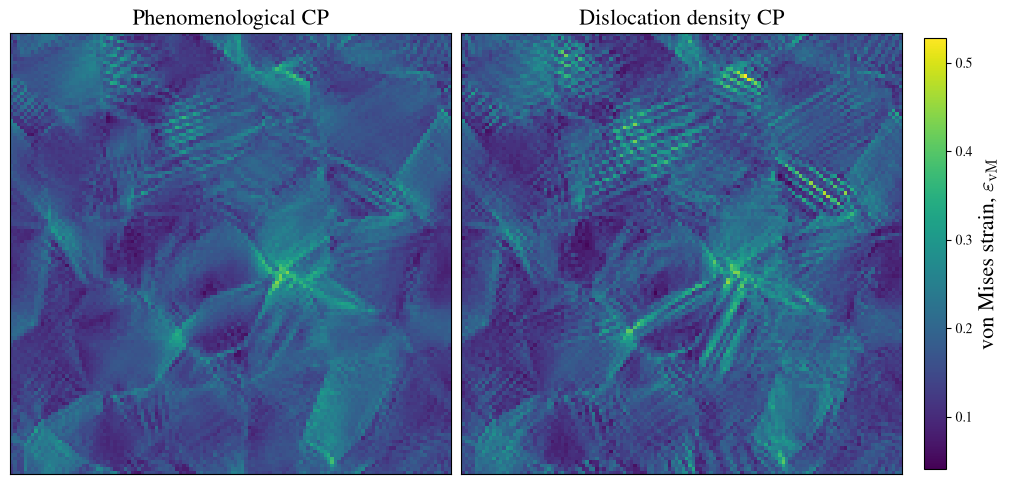

In [13]:
comparison_map(np.flip(pheno_vM_strain_load[:,:,0].transpose(), axis=0), 
               np.flip(dislo_vM_strain_load[:,:,0].transpose(), axis=0), 
               "Phenomenological CP",
               "Dislocation density CP",
               r"von Mises strain, $\varepsilon_{\text{vM}}$")

Extract strain maps

In [ ]:
def extract_strain_maps(file, rve_shape, layer, direction):

    '''
    Extract and plot strain maps from DAMASK HDF5 file

    direction: {'xy', 'yz', 'xz'}
        
    '''

    result = damask.Result(file)

    try:
        result.add_strain()
        result.add_stress_Cauchy()
        result.add_IPF_color(l=(0,0,1))

    except:
        pass

    increment = result.increments[-1]

    x = result.view(increments = increment)
 
    if direction == 'xy':
        strain_map_array = x.place('epsilon_V^0(F)')[:,0,0].reshape(rve_shape,order='F')[:,:,layer].transpose()

    if direction == 'yz':
        strain_map_array = x.place('epsilon_V^0(F)')[:,0,0].reshape(rve_shape,order='F')[layer,:,:].transpose()

    if direction == 'xz':
        strain_map_array = x.place('epsilon_V^0(F)')[:,0,0].reshape(rve_shape,order='F')[:,layer,:].transpose()

    strain_map_array_flip_y = np.flip(strain_map_array, axis=0)
    #strain_map_array_flipped = np.flip(strain_map_array_flip_y, axis=1)

    return strain_map_array_flip_y

In [ ]:
pheno_strain_map_surface = extract_strain_maps(pheno_file, [128,128,128], layer = 0, direction = 'xy')
dislo_strain_map_surface = extract_strain_maps(dislo_file, [128,128,128], layer = 0, direction = 'xy')

In [ ]:
pheno_strain_map_central = extract_strain_maps(pheno_file, [128,128,128], layer = 15, direction = 'xy')
dislo_strain_map_central = extract_strain_maps(dislo_file, [128,128,128], layer = 15, direction = 'xy')

In [ ]:
%matplotlib inline

fig_strain, ax_strain = plt.subplots(1,2, figsize = (10,6), sharey = True, sharex=True, constrained_layout=True)

pheno_strain_im = ax_strain[0].imshow(pheno_strain_map_surface, vmin = min(min(value) for value in (pheno_strain_map_surface.flatten(), dislo_strain_map_surface.flatten())), vmax = max(max(value) for value in (pheno_strain_map_surface.flatten(), dislo_strain_map_surface.flatten())))
dislo_strain_im = ax_strain[1].imshow(dislo_strain_map_surface, vmin = min(min(value) for value in (pheno_strain_map_surface.flatten(), dislo_strain_map_surface.flatten())), vmax = max(max(value) for value in (pheno_strain_map_surface.flatten(), dislo_strain_map_surface.flatten())))
#cbar1 = fig.colorbar(pheno_strain_im, orientation = 'vertical')
cbar2 = fig_strain.colorbar(dislo_strain_im, orientation = 'vertical', shrink = 0.73)
#cbar1.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
cbar2.set_label(r'True strain, $\varepsilon_{xx}$', rotation = 90, fontsize = 16, math_fontfamily = 'cm')
ax_strain[0].set_title('Phenopowerlaw', fontsize = 16)
ax_strain[1].set_title('Dislotwin', fontsize = 16)
ax_strain[0].set_xticks([])
ax_strain[1].set_xticks([])
ax_strain[0].set_yticks([])
ax_strain[1].set_yticks([])

# 2. Stress triaxiality

In [18]:
def calc_full_triaxiality(file, rve_shape):
    result = damask.Result(file)

    x = result.view(increments = result.increments[-1])

    try:
        x.add_spherical('sigma')
        x.add_equivalent_Mises('sigma')
    
    except:
        pass

    hydrostatic_stress = x.place('p_sigma')
    vM_stress = x.place('sigma_vM')

    hydrostatic_stress_map = hydrostatic_stress.reshape(rve_shape,order='F')
    vM_stress_map = vM_stress.reshape(rve_shape,order='F')

    triaxiality = hydrostatic_stress_map/vM_stress_map

    return triaxiality

In [22]:
pheno_triax = calc_full_triaxiality(pheno_file, [128,128,128])
#np.save('pheno_triax_200_grains.npy', pheno_triax)

In [23]:
dislo_triax = calc_full_triaxiality(dislo_file, [128,128,128])
#np.save('dislo_triax_200_grains.npy', dislo_triax)

In [21]:
pheno_triax_load = np.load('pheno_triax_200_grains.npy')
dislo_triax_load = np.load('dislo_triax_200_grains.npy')

ValueError: cannot reshape array of size 0 into shape (128,128,128)

In [25]:
pheno_triax_flat = pheno_triax.flatten()
dislo_triax_flat = dislo_triax.flatten()

/mnt/iusers01/jf01/j38714mw/software/venvs/matflow_v4-venv/lib/python3.11/site-packages/numpy/lib/function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


-0.309547211516161 0.3275145371596641


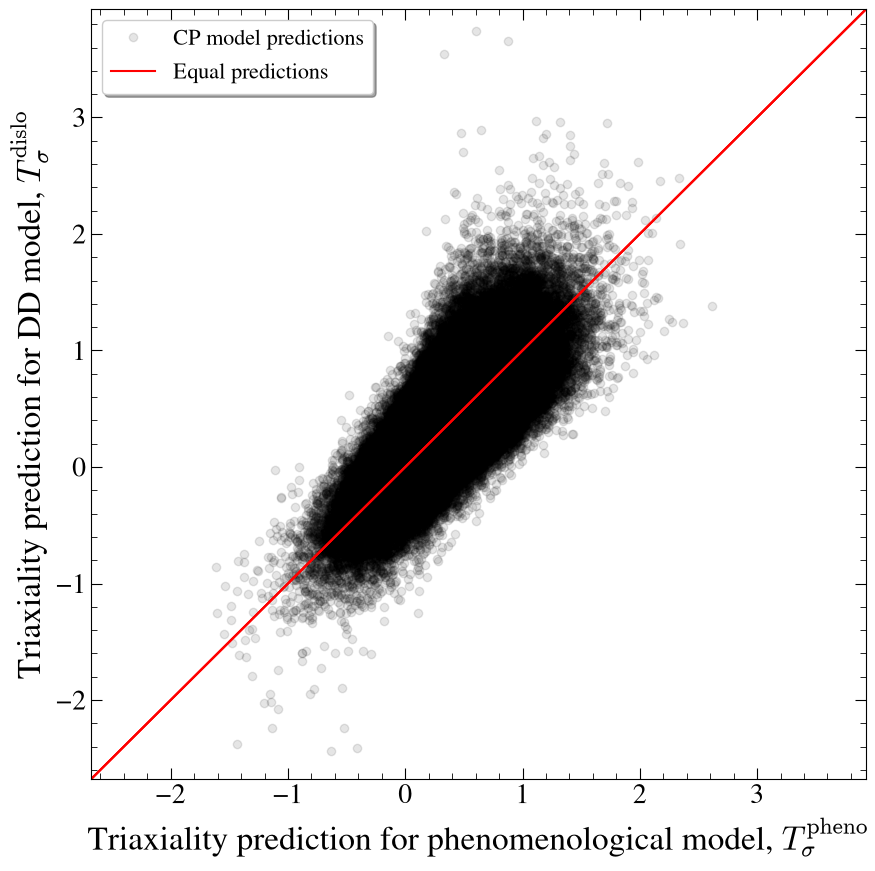

In [26]:
comparison_utils.comparison_plot(pheno_triax_flat, dislo_triax_flat,
                diag_line_start=[min(min(pheno_triax_flat), min(dislo_triax_flat)) - 0.1*np.abs(min(min(pheno_triax_flat), min(dislo_triax_flat))), min(min(pheno_triax_flat), min(dislo_triax_flat)) - 0.1*np.abs(min(min(pheno_triax_flat), min(dislo_triax_flat)))],
                min_interval = min(min(pheno_triax_flat), min(dislo_triax_flat)) - 0.1*np.abs(min(min(pheno_triax_flat), min(dislo_triax_flat))),
                max_interval = max(max(pheno_triax_flat), max(dislo_triax_flat)) + 0.05*np.abs(max(max(pheno_triax_flat), max(dislo_triax_flat))),
                xlabel = r'Triaxiality prediction for phenomenological model, $T_{\sigma}^{\text{pheno}}$',
                ylabel = r'Triaxiality prediction for DD model, $T_{\sigma}^{\text{dislo}}$',
                add_r2_score= False
                )
#plt.savefig('final_VE_triaxiality_predictions_comparison.png', dpi = 800)

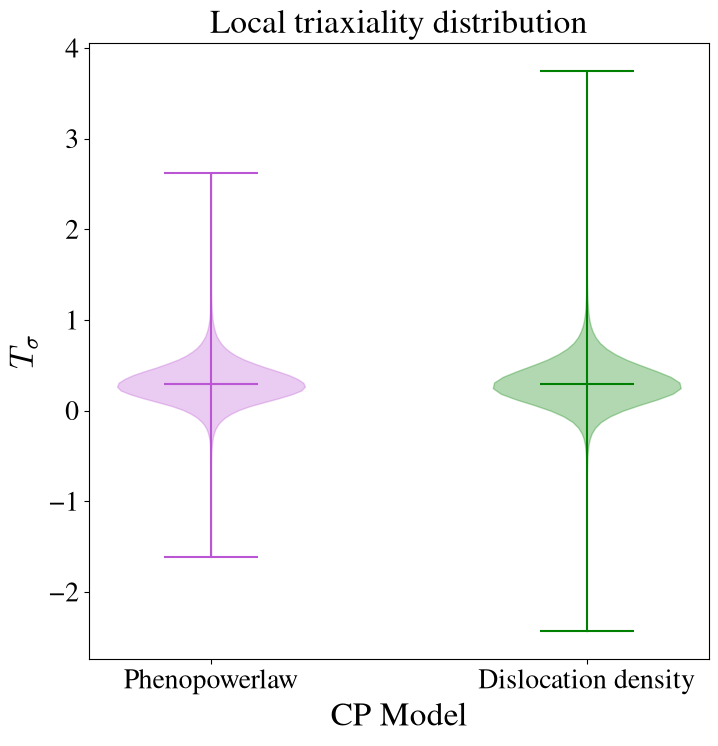

In [27]:
comparison_utils.violin_plot(pheno_triax_flat, dislo_triax_flat, title = 'Local triaxiality distribution', qoi = r'$T_{\sigma}$')
#plt.savefig('stress_triax_violin_plot.png', dpi=800)

# Using initial easy triax extraction for map plotting

In [29]:
#pheno_surface_triax = pheno_triax[:,:,0].transpose()
pheno_surface_triax = pheno_triax[:,:,0].transpose()
#dislo_surface_triax = dislo_triax[:,:,0].transpose()
dislo_surface_triax = dislo_triax[:,:,0].transpose()

pheno_surface_triax_flip = np.flip(pheno_surface_triax, axis=0)
dislo_surface_triax_flip = np.flip(dislo_surface_triax, axis=0)

# Kernel averaging

3D convolution

In [31]:
pheno_triax_3x3x3_avg = scipy.ndimage.convolve(pheno_triax, weights = [[[1/27,1/27,1/27], [1/27,1/27,1/27], [1/27,1/27,1/27]],
                                                                          [[1/27,1/27,1/27], [1/27,1/27,1/27], [1/27,1/27,1/27]],
                                                                          [[1/27,1/27,1/27], [1/27,1/27,1/27], [1/27,1/27,1/27]]])
dislo_triax_3x3x3_avg = scipy.ndimage.convolve(dislo_triax, weights = [[[1/27,1/27,1/27], [1/27,1/27,1/27], [1/27,1/27,1/27]],
                                                                          [[1/27,1/27,1/27], [1/27,1/27,1/27], [1/27,1/27,1/27]],
                                                                          [[1/27,1/27,1/27], [1/27,1/27,1/27], [1/27,1/27,1/27]]])

In [33]:
pheno_surface_triax_3x3x3_avg_vol = pheno_triax_3x3x3_avg[:,:,0].transpose()
pheno_surface_triax_3x3x3_avg_vol_flip = np.flip(pheno_surface_triax_3x3x3_avg_vol, axis=0)

dislo_surface_triax_3x3x3_avg_vol = dislo_triax_3x3x3_avg[:,:,0].transpose()
dislo_surface_triax_3x3x3_avg_vol_flip = np.flip(dislo_surface_triax_3x3x3_avg_vol, axis=0)

[]

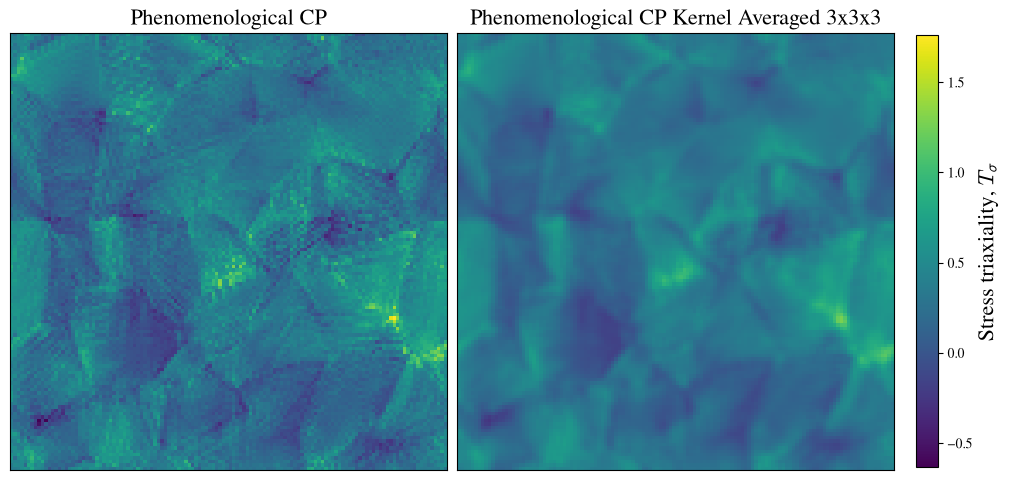

In [34]:
%matplotlib inline

fig_load_pheno_triax, ax_load_pheno_triax = plt.subplots(1,2, figsize = (10,6), sharey=True, sharex=True, constrained_layout=True)

pheno_load_triax_flip_im = ax_load_pheno_triax[0].imshow(pheno_surface_triax_flip, vmin = min(min(value) for value in (pheno_surface_triax_flip.flatten(), pheno_surface_triax_3x3x3_avg_vol_flip.flatten())), vmax = max(max(value) for value in (pheno_surface_triax_flip.flatten(), pheno_surface_triax_3x3x3_avg_vol_flip.flatten())))
pheno_load_triax_3x3x3_avg_im = ax_load_pheno_triax[1].imshow(pheno_surface_triax_3x3x3_avg_vol_flip, vmin = min(min(value) for value in (pheno_surface_triax_flip.flatten(), pheno_surface_triax_3x3x3_avg_vol_flip.flatten())), vmax = max(max(value) for value in (pheno_surface_triax_flip.flatten(), pheno_surface_triax_3x3x3_avg_vol_flip.flatten())))
cbar_load_pheno_triax = fig_load_pheno_triax.colorbar(pheno_load_triax_3x3x3_avg_im, orientation = 'vertical', shrink=0.73)
#cbar1.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
cbar_load_pheno_triax.set_label(r'Stress triaxiality, $T_{\sigma}$', rotation = 90, fontsize = 16, math_fontfamily = 'cm')
#ax_load_triax[0].annotate(text = 'Layer 0, XY', xy = [1,7], color = 'w', fontsize = 20)
ax_load_pheno_triax[0].set_title('Phenomenological CP', fontsize = 16)
ax_load_pheno_triax[1].set_title('Phenomenological CP Kernel Averaged 3x3x3', fontsize = 16)
ax_load_pheno_triax[0].set_xticks([])
ax_load_pheno_triax[1].set_xticks([])
ax_load_pheno_triax[0].set_yticks([])
ax_load_pheno_triax[1].set_yticks([])

Volume kernel-averaged comparison

[]

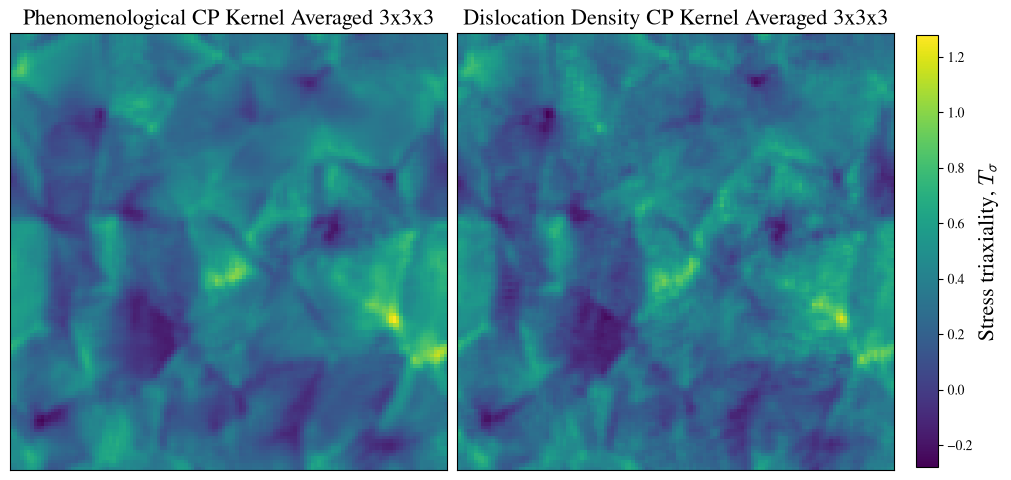

In [35]:
%matplotlib inline

fig_vol_avg_triax, ax_vol_avg_triax = plt.subplots(1,2, figsize = (10,6), sharey=True, sharex=True, constrained_layout=True)

pheno_vol_avg_im = ax_vol_avg_triax[0].imshow(pheno_surface_triax_3x3x3_avg_vol_flip, vmin = min(min(value) for value in (pheno_surface_triax_3x3x3_avg_vol_flip.flatten(), dislo_surface_triax_3x3x3_avg_vol_flip.flatten())), vmax = max(max(value) for value in (pheno_surface_triax_3x3x3_avg_vol_flip.flatten(), dislo_surface_triax_3x3x3_avg_vol_flip.flatten())))
dislo_vol_avg_im = ax_vol_avg_triax[1].imshow(dislo_surface_triax_3x3x3_avg_vol_flip, vmin = min(min(value) for value in (pheno_surface_triax_3x3x3_avg_vol_flip.flatten(), dislo_surface_triax_3x3x3_avg_vol_flip.flatten())), vmax = max(max(value) for value in (pheno_surface_triax_3x3x3_avg_vol_flip.flatten(), dislo_surface_triax_3x3x3_avg_vol_flip.flatten())))
cbar_vol_avg_triax = fig_vol_avg_triax.colorbar(dislo_vol_avg_im, orientation = 'vertical', shrink=0.73)
#cbar1.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
cbar_vol_avg_triax.set_label(r'Stress triaxiality, $T_{\sigma}$', rotation = 90, fontsize = 16, math_fontfamily = 'cm')
#ax_load_triax[0].annotate(text = 'Layer 0, XY', xy = [1,7], color = 'w', fontsize = 20)
ax_vol_avg_triax[0].set_title('Phenomenological CP Kernel Averaged 3x3x3', fontsize = 16)
ax_vol_avg_triax[1].set_title('Dislocation Density CP Kernel Averaged 3x3x3', fontsize = 16)
ax_vol_avg_triax[0].set_xticks([])
ax_vol_avg_triax[1].set_xticks([])
ax_vol_avg_triax[0].set_yticks([])
ax_vol_avg_triax[1].set_yticks([])

# Statistical comparison

In [39]:
def statistical_comparison_metrics(pheno_vals, dislo_vals):
    max_val = max(max(pheno_vals.flatten(order = 'F')), max(dislo_vals.flatten(order = 'F')))
    min_val = min(min(pheno_vals.flatten(order = 'F')), min(dislo_vals.flatten(order = 'F')))

    nrmse_pheno_norm = np.sqrt(np.mean((pheno_vals - dislo_vals)**2))/np.mean(np.abs(pheno_vals))
    nrmse_dislo_norm = np.sqrt(np.mean((pheno_vals - dislo_vals)**2))/np.mean(np.abs(dislo_vals))
    ssim_score = skimage.metrics.structural_similarity(pheno_vals, dislo_vals, data_range = max_val - min_val)
    corr_coeff = np.corrcoef(pheno_vals.ravel(), dislo_vals.ravel())[0,1]
    mean_err = np.abs(np.mean(pheno_vals.flatten()) - np.mean(dislo_vals.flatten()))/(np.mean(pheno_vals.flatten()))
    print(f'NRMSE (pheno normalised): {nrmse_pheno_norm:.3f} \nNRMSE (dislo normalised): {nrmse_dislo_norm:.3f} \nSSIM: {ssim_score:.3f} \nCorrelation coefficient: {corr_coeff:.3f} \nMean error: {mean_err:.5f}')

Comparison for strain on original $128^3$ VEs

In [40]:
statistical_comparison_metrics(pheno_xx_strain, dislo_xx_strain)

NRMSE (pheno normalised): 0.174 
NRMSE (dislo normalised): 0.174 
SSIM: 0.698 
Correlation coefficient: 0.814 
Mean error: 0.00235


Comparison for triaxiality on original $128^3$ VEs

In [41]:
statistical_comparison_metrics(pheno_triax, dislo_triax)

NRMSE (pheno normalised): 0.504 
NRMSE (dislo normalised): 0.496 
SSIM: 0.721 
Correlation coefficient: 0.772 
Mean error: 0.00949


Comparison for triaxiality with 3x3x3 kernel averaging

In [42]:
statistical_comparison_metrics(pheno_triax_3x3x3_avg, dislo_triax_3x3x3_avg)

NRMSE (pheno normalised): 0.195 
NRMSE (dislo normalised): 0.196 
SSIM: 0.876 
Correlation coefficient: 0.947 
Mean error: 0.00949


[]

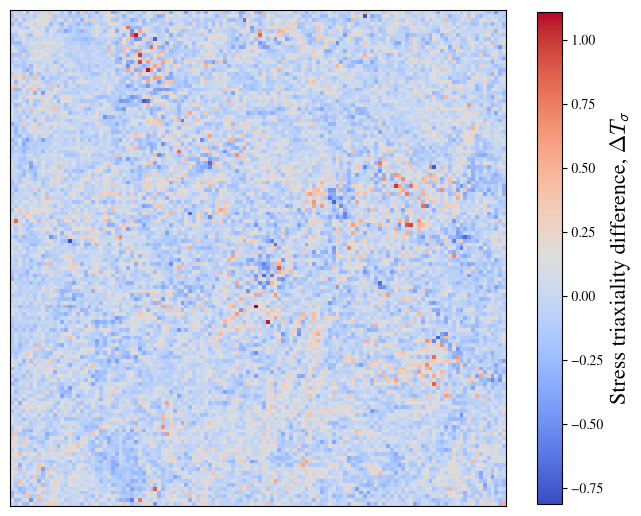

In [43]:
# Difference plot
triax_diff = dislo_surface_triax_flip - pheno_surface_triax_flip
fig_triax_diff, ax_triax_diff = plt.subplots(1,1, figsize = (8,8))

triax_diff_im = ax_triax_diff.imshow(triax_diff, cmap = 'coolwarm')
cbar_triax_diff = fig_triax_diff.colorbar(triax_diff_im, orientation = 'vertical', shrink = 0.8)
cbar_triax_diff.set_label(r'Stress triaxiality difference, $\Delta T_{\sigma}$', rotation = 90, fontsize = 16, math_fontfamily = 'cm')
ax_triax_diff.set_xticks([])
ax_triax_diff.set_yticks([])

In [ ]:
def calc_triaxiality_2D(file, rve_shape, layer, direction):
    result = damask.Result(file)

    try:
        result.add_spherical('sigma')
        result.add_equivalent_Mises('sigma')
        
    except:
        pass

    x = result.view(increments = result.increments[-1])

    if direction == 'xy':
        hydrostatic_stress = x.get('p_sigma').reshape(rve_shape,order='F')[:,:,layer].transpose()
        vM_stress = x.get('sigma_vM').reshape(rve_shape,order='F')[:,:,layer].transpose()
        
    if direction == 'yz':
        hydrostatic_stress = x.get('p_sigma').reshape(rve_shape,order='F')[layer,:,:].transpose()
        vM_stress = x.get('sigma_vM').reshape(rve_shape,order='F')[layer,:,:].transpose()

    if direction == 'xz':
        hydrostatic_stress = x.get('p_sigma').reshape(rve_shape,order='F')[:,layer,:].transpose()
        vM_stress = x.get('sigma_vM').reshape(rve_shape,order='F')[:,layer,:].transpose()

    hydrostatic_stress_flipped = np.flip(hydrostatic_stress, axis=0)
    vM_stress_flipped = np.flip(vM_stress, axis=0)

    triaxiality = hydrostatic_stress_flipped/vM_stress_flipped

    return triaxiality

In [ ]:
pheno_triax_surface_layer = calc_triaxiality_2D(pheno_file, rve_shape = [128,128,128], layer = 0, direction = 'xy')
print('Pheno map extracted!')
dislo_triax_surface_layer = calc_triaxiality_2D(dislo_file, rve_shape = [128,128,128], layer = 0, direction = 'xy')
print('Dislo map extracted!')

In [ ]:
%matplotlib inline

fig_triax, ax_triax = plt.subplots(1,2, figsize = (10,6), sharey=True, sharex=True, constrained_layout=True)

pheno_triax_im = ax_triax[0].imshow(pheno_triax_surface_layer, vmin = min(min(value) for value in (pheno_triax_surface_layer.flatten(), dislo_triax_surface_layer.flatten())), vmax = max(max(value) for value in (pheno_triax_surface_layer.flatten(), dislo_triax_surface_layer.flatten())))
dislo_triax_im = ax_triax[1].imshow(dislo_triax_surface_layer, vmin = min(min(value) for value in (pheno_triax_surface_layer.flatten(), dislo_triax_surface_layer.flatten())), vmax = max(max(value) for value in (pheno_triax_surface_layer.flatten(), dislo_triax_surface_layer.flatten())))
cbar_triax = fig_triax.colorbar(dislo_triax_im, orientation = 'vertical', shrink=0.73)
#cbar1.set_label('True strain, $\epsilon_{xx}$', rotation = 90, fontsize = 16)
cbar_triax.set_label('Stress triaxiality, $T_{\sigma,xx}$', rotation = 90, fontsize = 16)
ax_triax[0].annotate(text = 'Layer 0, XY', xy = [1,7], color = 'w', fontsize = 20)
ax_triax[0].set_title('Phenopowerlaw', fontsize = 16)
ax_triax[1].set_title('Dislotwin', fontsize = 16)
ax_triax[0].set_xticks([])
ax_triax[1].set_xticks([])
ax_triax[0].set_yticks([])
ax_triax[1].set_yticks([])

# 3. Plastic work

In [ ]:
def calc_plastic_work_full(damask_file, mat_file, rve_shape, full = True, slip_system = None):
    result = damask.Result(damask_file)
    x = result.view(increments = result.increments[-1])

    if full == True:
        rve_shape_ext = [128,128,128,12]
        #gamma = x.place('gamma_sl')
        gamma = x.get('gamma_sl').reshape(rve_shape_ext, order = 'F')
    if full == False:
        #gamma = x.place('gamma_sl')[:,slip_system]
        gamma = x.get('gamma_sl')[:,slip_system].reshape(rve_shape, order = 'F')

    mat = damask.ConfigMaterial.load(mat_file)
    crystal_structure = damask.Crystal(lattice = mat['phase']['Cu']['lattice'])

    if full == True:
        slip_dirs = crystal_structure.kinematics('slip')['direction'][0]
        slip_norms = crystal_structure.kinematics('slip')['plane'][0]

    if full == False:
        slip_dirs = crystal_structure.kinematics('slip')['direction'][0][slip_system]
        slip_norms = crystal_structure.kinematics('slip')['plane'][0][slip_system]

    #print(slip_dirs, slip_norms)

    rot_matrices = damask.Rotation(x.get('O')).reshape(rve_shape, order = 'F').as_matrix()
    #print(len(rot_matrices))

    # Calculate final orientations of material points

    all_new_slip_dirs = []
    all_new_slip_norms = []

    for i in range(len(rot_matrices)):
        new_slip_dirs = []
        new_slip_norms = []
        for j in range(len(slip_dirs)):
            new_slip_dir = rot_matrices[i] @ slip_dirs[j]
            new_slip_norm = rot_matrices[i] @ slip_norms[j]
            new_slip_dirs.append(new_slip_dir)
            new_slip_norms.append(new_slip_norm)
        
        all_new_slip_dirs.append(new_slip_dirs)
        all_new_slip_norms.append(new_slip_norms)

    sigma = x.get('sigma').reshape([128,128,128,3,3], order = 'F')

    print(np.array(sigma.shape), np.array(all_new_slip_dirs).shape, np.array(all_new_slip_norms).shape)
    
    # Calculate resolved shear stresses
    tau = np.einsum('vij,vsi,vsj->vs', sigma, all_new_slip_dirs, all_new_slip_norms)
    #print(tau.shape)

    if full == True:
        tau_slip = tau.reshape(rve_shape_ext, order = 'F')

    if full == False:
        tau_slip = tau[:,slip_system].reshape(rve_shape, order = 'F').transpose()

    plastic_work = np.multiply(gamma, tau_slip)

    return plastic_work

In [ ]:
pheno_mat_file = './phenopowerlaw/second_year_report_calibrated_values/phenopowerlaw_128_rolled_copper_5k_time_steps_2026-06-22_142935/execute/t_1/material.yaml'
dislo_mat_file = './dislo_density/second_year_report_calibrated_values/dislotwin_128_rolled_copper_5k_time_steps_2026-06-22_142808/execute/t_1/material.yaml'

In [ ]:
pheno_plastic_work_full = calc_plastic_work_full(pheno_file, pheno_mat_file, rve_shape=[128,128,128])

In [ ]:
dislo_plastic_work_full = calc_plastic_work_full(dislo_file, dislo_mat_file, rve_shape=[128,128,128])

# 4. r-value

In [33]:
dislo_result = damask.Result(dislo_file)
dislo_test_inc = dislo_result.view(increments= dislo_result.increments[::10])

In [37]:
import tqdm
r_vals_test = []
for increment in tqdm.tqdm(dislo_result.increments[::10]):
    dislo_test_inc_i = dislo_result.view(increments = increment)
    try:
        dislo_test_inc_i.add_strain('F_p','U')
        dislo_test_inc_i.add_stretch_tensor('F_p',t='U')
    except:
        pass
    plastic_strain_tensor_test = dislo_test_inc_i.get('epsilon_U^0.0(F_p)')
    r_val_test = (np.average(plastic_strain_tensor_test[:,2,2]))/(np.average(plastic_strain_tensor_test[:,1,1]))
    r_vals_test.append(r_val_test)
print(r_vals_test)

  9%|▉         | 1/11 [00:42<07:00, 42.10s/it]


TypeError: 'NoneType' object is not subscriptable

In [27]:
# Calculating r-value
(np.average(dislo_test_inc.get('epsilon_U^0.0(F_p)')[:,2,2]))/(np.average(dislo_test_inc.get('epsilon_U^0.0(F_p)')[:,1,1]))

np.float64(0.8577287929900369)

In [ ]:
# Calculating plastic vM strain
epsilon_F_p = damask.mechanics.strain(dislo_test_inc.get('U(F_p)'), t = 'U', m = 0.0)
epsilon_F_p_vM = damask.mechanics.equivalent_strain_Mises(epsilon_F_p)
epsilon_F_p_vM

array([0.11452837, 0.21076569, 0.1413901 , ..., 0.20068844, 0.14496029,
       0.10987572], shape=(2097152,))

In [20]:
np.average(epsilon_F_p_vM)

np.float64(0.1683610650293248)

In [55]:
# Option 1, r-value from local plastic strain

def calc_r_value(damask_file):
    result = damask.Result(damask_file)

    #x = result.view(increments = result.increments[::10])#[::5])
    r_vals = []
    equiv_vM_strains = []

    for increment in tqdm.tqdm(result.increments[::5]):

        x = result.view(increments = increment)

        try:
            x.add_strain('F_p','U')
            x.add_stretch_tensor('F_p',t='U')
        except:
            pass

        plastic_strain_tensor = x.get('epsilon_U^0.0(F_p)')

        # Calculating r-value
        r_value = (np.average(plastic_strain_tensor[:,2,2]))/(np.average(plastic_strain_tensor[:,1,1]))

        # Calculating plastic vM strain
        epsilon_F_p_vM = damask.mechanics.equivalent_strain_Mises(plastic_strain_tensor)
        epsilon_F_p_vM_avg = np.average(epsilon_F_p_vM)

        r_vals.append(r_value)
        equiv_vM_strains.append(epsilon_F_p_vM_avg)

    return equiv_vM_strains, r_vals

In [41]:
pheno_vM_strains, pheno_r_vals = calc_r_value(pheno_file)

100%|██████████| 11/11 [06:19<00:00, 34.48s/it]


In [43]:
np.save("pheno_vM_strains_avg_10_time_steps.npy", pheno_vM_strains)
np.save("pheno_r_vals_10_time_steps.npy", pheno_r_vals)

In [56]:
pheno_vM_strains_20_incs, pheno_r_vals_20_incs = calc_r_value(pheno_file)

100%|██████████| 21/21 [04:09<00:00, 11.90s/it]


In [57]:
np.save("pheno_vM_strains_avg_20_time_steps.npy", pheno_vM_strains_20_incs)
np.save("pheno_r_vals_20_time_steps.npy", pheno_r_vals_20_incs)

In [44]:
dislo_vM_strains, dislo_r_vals = calc_r_value(dislo_file)

100%|██████████| 11/11 [02:59<00:00, 16.35s/it]


In [46]:
np.save("dislo_vM_strains_avg_10_time_steps.npy", dislo_vM_strains)
np.save("dislo_r_vals_10_time_steps.npy", dislo_r_vals)

In [58]:
dislo_vM_strains_20_incs, dislo_r_vals_20_incs = calc_r_value(dislo_file)

100%|██████████| 21/21 [04:10<00:00, 11.94s/it]


In [59]:
np.save("dislo_vM_strains_avg_20_time_steps.npy", dislo_vM_strains_20_incs)
np.save("dislo_r_vals_20_time_steps.npy", dislo_r_vals_20_incs)

(0.0, 1.0)

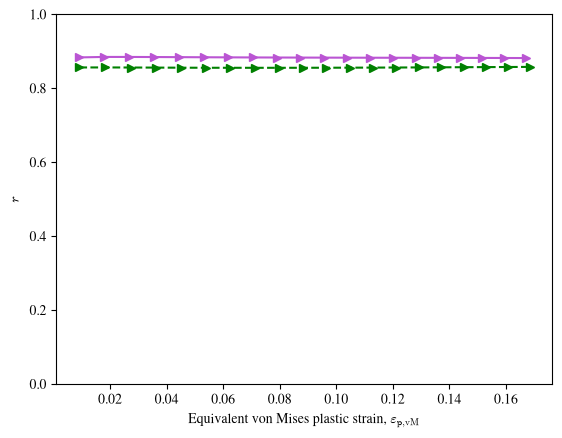

In [64]:
fig_r_val, ax_r_val = plt.subplots()
ax_r_val.plot(pheno_vM_strains_20_incs[1:], pheno_r_vals_20_incs[1:], color = 'mediumorchid', ls = '-', marker = '>')
ax_r_val.plot(dislo_vM_strains_20_incs[1:], dislo_r_vals_20_incs[1:], 'g--', marker = '>')
ax_r_val.set_ylabel(r"$r$", math_fontfamily = 'cm')
ax_r_val.set_xlabel(r"Equivalent von Mises plastic strain, $\varepsilon_{\text{p,vM}}$", math_fontfamily = 'cm')
ax_r_val.set_ylim(0,1)

In [31]:
pheno_vM_strain, dislo_vM_strain

(np.float64(0.16690788017082497), np.float64(0.1683610650293248))

In [32]:
pheno_r_val, dislo_r_val

(np.float64(0.8816777048578106), np.float64(0.8577287929900369))

In [ ]:
dislo_test_result = damask.Result(dislo_file)
try:
    dislo_test_result.add_strain('F_p','U')
    dislo_test_result.add_stretch_tensor('F_p',t='U')
except:
    pass

In [ ]:
dislo_test_result

In [ ]:
dislo_vM_strain, dislo_r_val = calc_r_value(dislo_file)

In [ ]:
np.save("pheno_128_vM_strain.npy",pheno_vM_strain)
#np.save("dislo_128_vM_strain.npy",dislo_vM_strain)
np.save("pheno_128_vM_r_val.npy",pheno_r_val)
#np.save("dislo_128_vM_r_val.npy",dislo_r_val)

In [ ]:
%matplotlib inline
fig_r_val, ax_r_val = plt.subplots(1,1, figsize = (10,6))

ax_r_val.plot(pheno_vM_strain, pheno_r_val, ls = '--', label = 'Phenopowerlaw')
#ax_r_val.plot(dislo_vM_strain, dislo_r_val, ls = '-', label = 'Dislotwin')
ax_r_val.set_xlabel('von Mises strain')
ax_r_val.set_ylabel('r-value')

ax_r_val.legend(shadow = True)